In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"..\data\freelancers_dataset_updated.csv")

In [3]:
df.head()

,role_category,hourly_rate,bio,avg_rating,num_reviews,num_certifications,profile_score,time_to_respond,last_active,is_professional_photo,mentorship_offered,skills,num_projects
0,AI Engineer,49.284158,deep learning researcher with solid experience...,4.386670,22,3,76.363640,9,5,True,False,"Docker, Azure ML, NumPy, AWS SageMaker, Genera...",28
1,AI Engineer,49.715610,Professional systems/ml engineer specializing ...,5.000000,44,7,98.703363,1,1,True,True,"Pandas, Computer Vision, Docker, XGBoost, Obje...",32
2,AI Engineer,37.548454,Experienced Software Engineer with 2+ years in...,4.667451,26,3,82.268190,1,4,False,False,"MLflow, Pinecone, Seaborn, Data Visualization,...",12
3,AI Engineer,25.310952,IT Specialist & Data Entry with solid experien...,4.184171,14,4,60.979209,13,6,False,False,"Pandas, Virtual Assistant, HTML, API Integrati...",4
4,AI Engineer,34.547086,systems/ml engineer with solid experience in A...,4.384751,27,5,81.637283,1,7,True,True,"Snowflake, OpenAI API, Databricks, RAG, BERT, ...",15


In [4]:
cols_to_drop = ['num_reviews', 'avg_rating']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

In [5]:
print("Shape after dropping columns:", df_clean.shape)

Shape after dropping columns: (22360, 11)


Text(0.5, 1.0, 'Distribution of Profile Score')

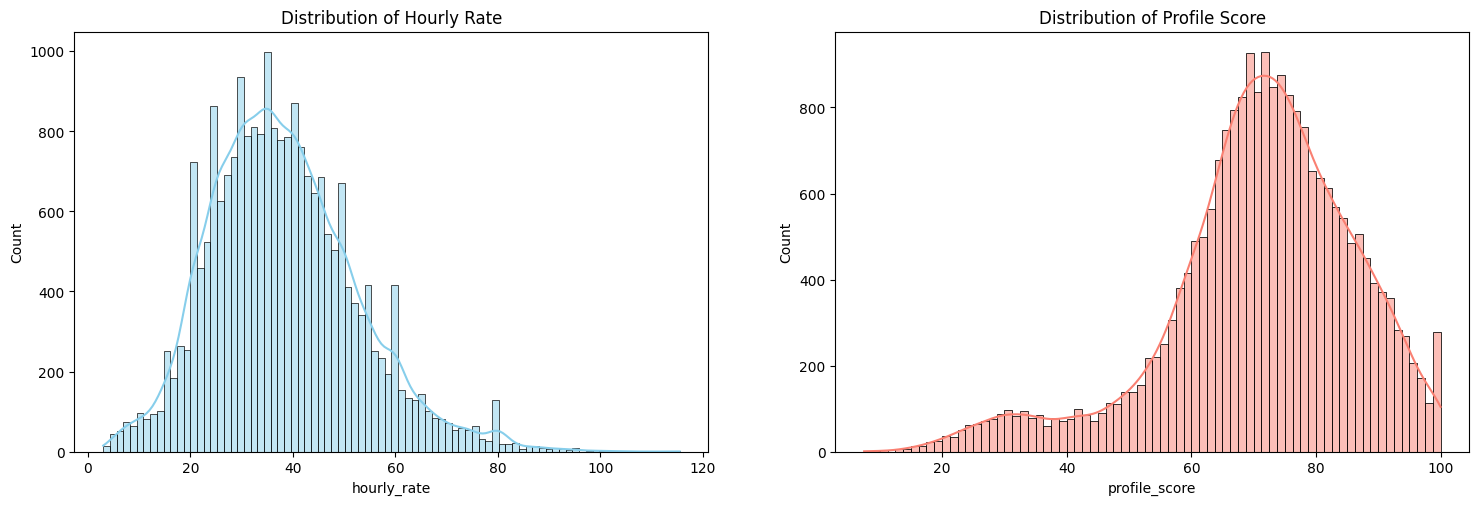

In [6]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.histplot(df_clean['hourly_rate'], kde=True, color='skyblue')
plt.title('Distribution of Hourly Rate')

plt.subplot(2, 2, 2)
sns.histplot(df_clean['profile_score'], kde=True, color='salmon')
plt.title('Distribution of Profile Score')

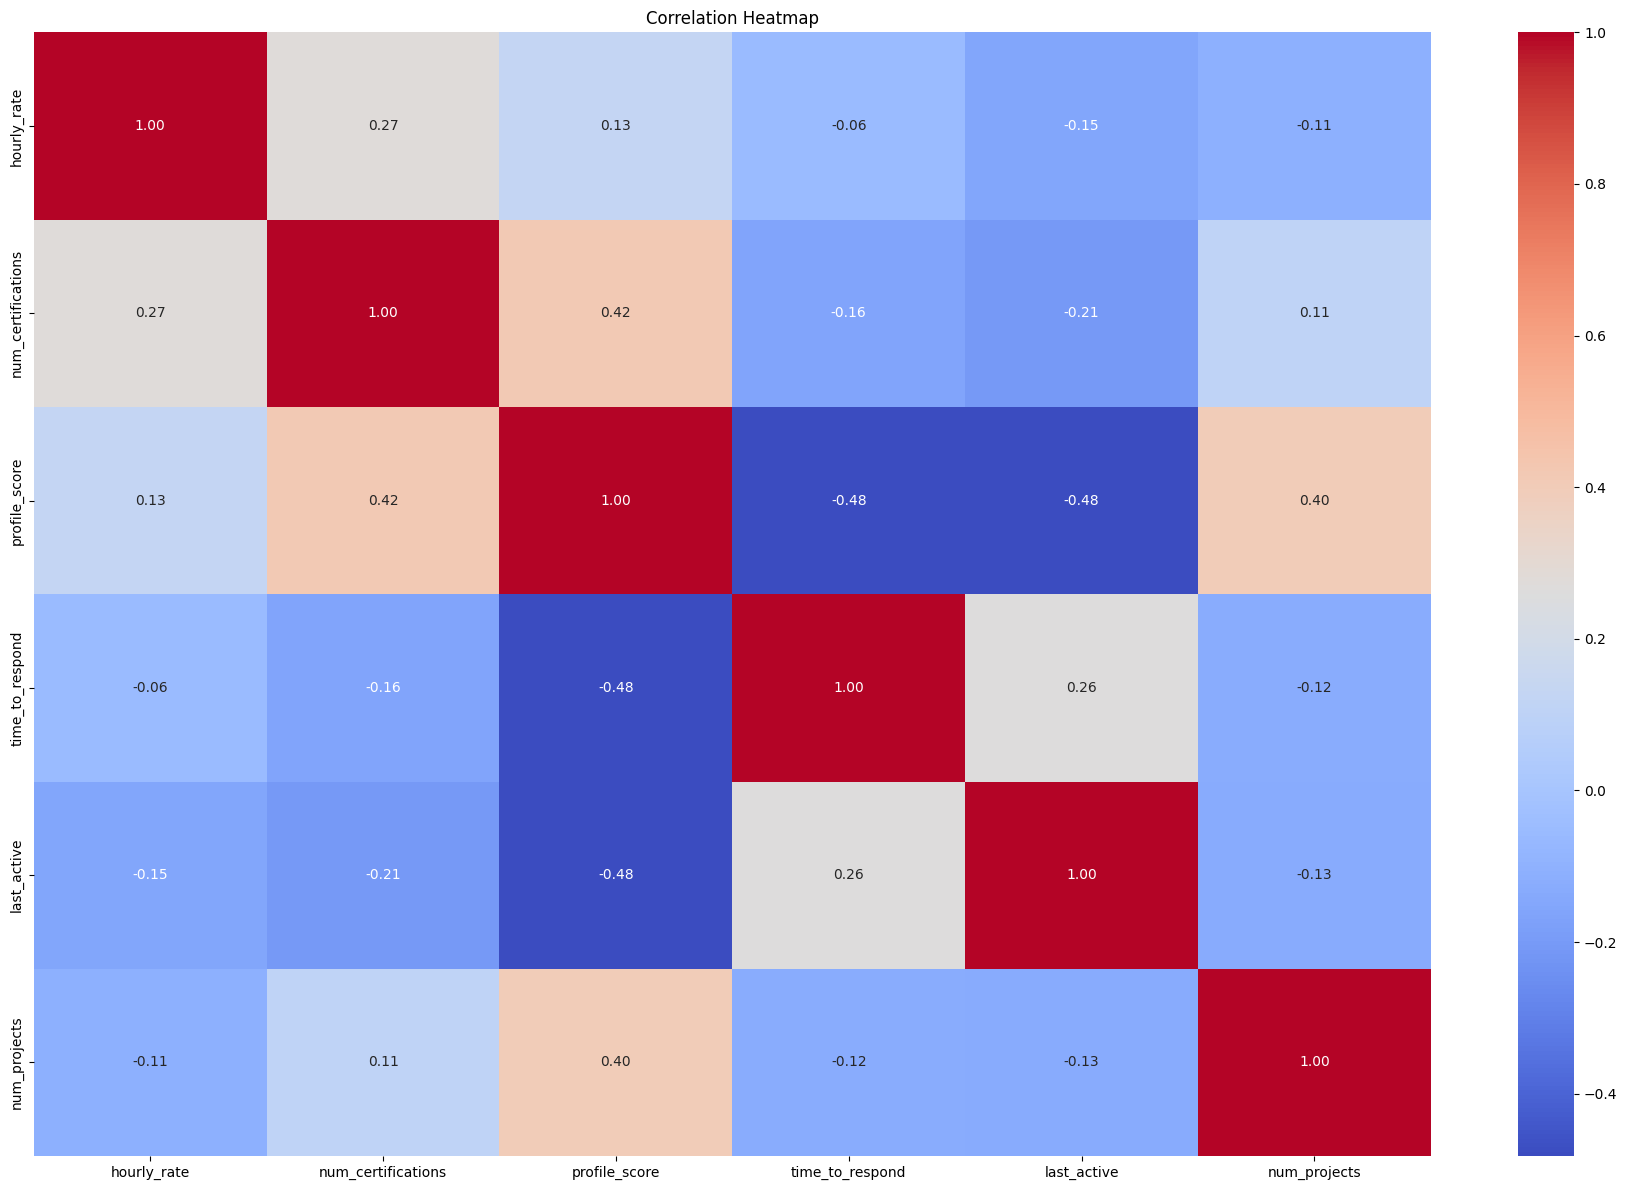

In [7]:
plt.figure(figsize=(18, 12))
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [8]:
print("\nImpact of Professional Photo:")
print(df_clean.groupby('is_professional_photo')[['profile_score']].mean())


Impact of Professional Photo:
                       profile_score
is_professional_photo               
False                      62.331322
True                       74.625461


In [9]:
print("\nImpact of Offering/Getting Mentorship:")
print(df_clean.groupby('mentorship_offered')[['profile_score']].mean())


Impact of Offering/Getting Mentorship:
                    profile_score
mentorship_offered               
False                   69.680251
True                    72.157210


In [10]:
df_clean.isna().sum()

role_category            0
hourly_rate              0
bio                      0
num_certifications       0
profile_score            0
time_to_respond          0
last_active              0
is_professional_photo    0
mentorship_offered       0
skills                   0
num_projects             0
dtype: int64

In [11]:
df_clean.duplicated().sum()

0